In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
# read in all words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [14]:
len(words)

32033

In [15]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(stoi)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [16]:
# build dataset splits
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X_list, Y_list = [], []
    for w in words:
        
        context = [0] * block_size # initialize with all start characters
        for ch in w + '.': # for each character plus the stop character
            ix = stoi[ch] # index of the character
            X_list.append(context) # add the current context to the inputs
            Y_list.append(ix) # add the next character to the targets
            context = context[1:] + [ix] # slide the context window, append the new character
            
    X = torch.tensor(X_list)
    Y = torch.tensor(Y_list)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])      # 80% training set
Xdev, Ydev = build_dataset(words[n1:n2])    # 10% development set
Xte,  Yte  = build_dataset(words[n2:])      # 10% test set
  
 

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [113]:
# MLP revisited

n_embd = 10 # the dimensionality of the character embeddings vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
gain = {
    'tanh': 5/3,
    'relu': (2)**0.5,
    'sigmoid': 1,
    'leaky_relu': (2 / (1 + 0.01 ** 2))**0.5
}
activation_function = 'tanh'
fan_in = n_embd * block_size

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1    = torch.randn((n_embd * block_size, n_hidden), generator=g) * float(gain[activation_function] / ((fan_in) ** 0.5)) # add `float` explictly to pass mypy type checking
b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # if you use batch norm, this is ignored and bnbias is used instead actually
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12297


In [114]:
# same optimization as last time
max_steps = 200000
minibatch_size = 32
lossi = []

for i in range(max_steps):
    # minibtach construction
    batch_indices = torch.randint(0, Xtr.shape[0], (minibatch_size,))
    Xb, Yb = Xtr[batch_indices], Ytr[batch_indices] # minibatch X and Y
    
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate the embeddings
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # layer of batch normalization
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact) # hidden layer activation
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # cross-entropy loss
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr  * p.grad # how do you determine the learning rate?
        
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    
    
        

      0/ 200000: 3.3092
  10000/ 200000: 2.3930
  20000/ 200000: 2.0966
  30000/ 200000: 2.4051
  40000/ 200000: 1.7479
  50000/ 200000: 2.4011
  60000/ 200000: 1.6134
  70000/ 200000: 1.8979
  80000/ 200000: 2.3071
  90000/ 200000: 2.3212
 100000/ 200000: 1.8810
 110000/ 200000: 1.9512
 120000/ 200000: 1.9553
 130000/ 200000: 2.3161
 140000/ 200000: 2.3348
 150000/ 200000: 2.1995
 160000/ 200000: 2.0466
 170000/ 200000: 2.1873
 180000/ 200000: 2.0838
 190000/ 200000: 2.0892


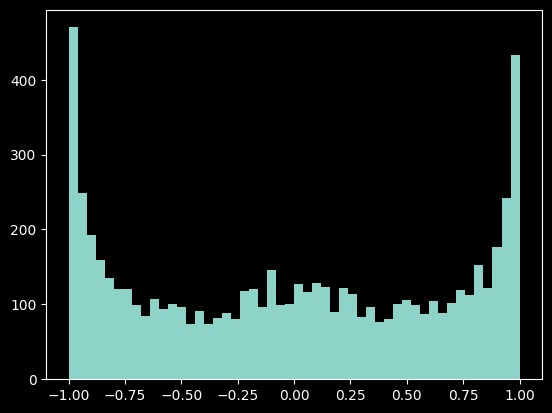

In [98]:
plt.hist(h.view(-1).tolist(), 50);

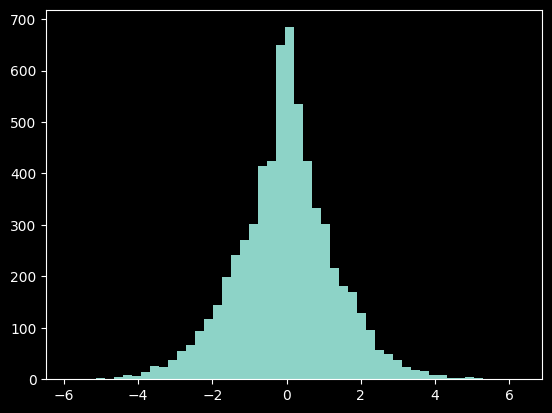

In [99]:
plt.hist(hpreact.view(-1).tolist(), 50);

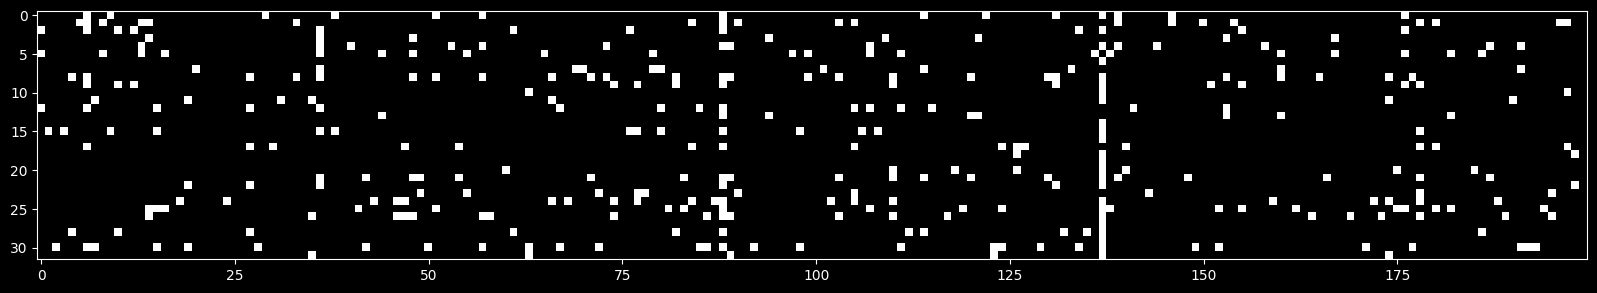

In [102]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

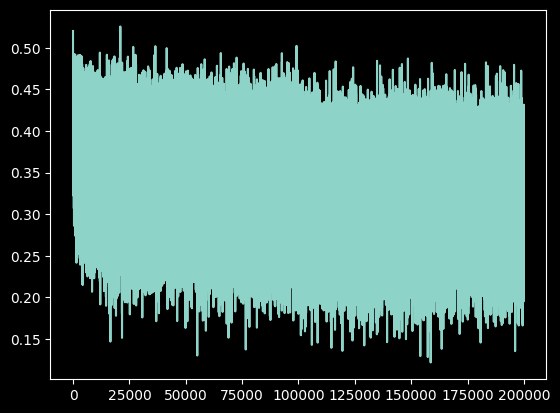

In [101]:
plt.plot(lossi)

In [86]:
@torch.no_grad() # this decorator disables gradient tracking for the code block
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr), 
        'dev': (Xdev, Ydev), 
        'test': (Xte, Yte)
    }[split]    
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concatenate into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # layer of batch normalization
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y) 
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('dev')

train loss: 2.0413
dev loss: 2.1091


In [111]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # start with all start characters
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        embcat = emb.view(1, -1) # (1, block_size * n_embd)
        h = torch.tanh(embcat @ W1 + b1) # (1, n_hidden)
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # (1, vocab_size)
        
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample from the distribution
         
        context = context[1:] + [ix] # slide the context window
        out.append(itos[ix])
        
        if ix == 0: # end of word token
            break
        
    print(''.join(out))

chrishfaabriquiffimrighthty.
hplannnedrncetlfahnsraciarquifnekourthchailvinsleighthsh.
pristquinton.
luvell.
vabruwluwap.
diarrigx.
khailivsanviktemi.
phntley.
luws.
hasquervariksya.
prabhib.
sunnnyn.
prinndrennkelsa.
luughnoussinslaznuxahmaqtaltynn.
phnnghannquhrivinda.
ffinnyiahnbvithvingtristyld.
kkmarnzekquinanakhlyn.
sunnikzameteve.
khaadya.
sorrio.


# the remaining part is focusing on 
1. PyTorch-liking coding parts
2. how to collect metrics to see if the network init is good or not
   1. layer.out(activation) distribution over all layers 
   2. layer.out.grad distribution over all layers
   3. weight grad distribution over all layers
   4. data change level distribution over all layers (观察数据变化幅度)
   5. 